# XAI Experiment Analysis

This notebook analyzes the results of molecule optimization experiments with different XAI settings:
- **Full XAI**: Complete explanations for all oracles
- **Partial XAI**: Partial explanations (QED only)
- **No XAI**: No explanations provided

We compare optimization performance across 5 repetitions for each XAI condition.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Define paths
RESULTS_DIR = Path("../data/results/similarity_qed")

# XAI mode mapping (folder name -> display name)
XAI_MODES = {
    "full_xai": "Full XAI",
    "partial_xai": "Partial XAI",
    "no_xai": "No XAI"
}

# Molecule types
MOLECULE_TYPES = ["relevant_molecule", "random_molecule"]

In [3]:
def load_experiment_data(json_path: Path) -> dict:
    """Load experiment data from a JSON file."""
    with open(json_path, 'r') as f:
        return json.load(f)


def extract_best_score_trajectory(trace: list[dict]) -> list[float]:
    """Extract the best score so far at each iteration from the trace."""
    best_scores = []
    best_so_far = float('-inf')
    
    for entry in trace:
        score = entry['score']
        best_so_far = max(best_so_far, score)
        best_scores.append(best_so_far)
    
    return best_scores


def load_all_experiments(results_dir: Path, molecule_type: str) -> dict[str, list[list[float]]]:
    """
    Load all experiments for a given molecule type.
    
    Returns a dict mapping XAI mode to list of trajectories (one per repetition).
    """
    data = {}
    
    for xai_folder, xai_name in XAI_MODES.items():
        folder_path = results_dir / molecule_type / xai_folder
        trajectories = []
        
        if folder_path.exists():
            json_files = sorted(folder_path.glob("*.json"))
            for json_file in json_files:
                exp_data = load_experiment_data(json_file)
                trajectory = extract_best_score_trajectory(exp_data['trace'])
                trajectories.append(trajectory)
        
        data[xai_name] = trajectories
    
    return data

In [4]:
def compute_stats(trajectories: list[list[float]], max_iterations: int = None) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute mean and confidence intervals from multiple trajectories.
    
    Returns:
        iterations: array of iteration indices
        mean: mean best score at each iteration
        ci: 95% confidence interval half-width (1.96 * std / sqrt(n))
    """
    if not trajectories:
        return np.array([]), np.array([]), np.array([])
    
    # Find the maximum length or use provided max
    if max_iterations is None:
        max_len = max(len(t) for t in trajectories)
    else:
        max_len = max_iterations
    
    # Pad trajectories to the same length (repeat last value)
    padded = []
    for t in trajectories:
        if len(t) < max_len:
            padded.append(t + [t[-1]] * (max_len - len(t)))
        else:
            padded.append(t[:max_len])
    
    arr = np.array(padded)
    mean = np.mean(arr, axis=0)
    std = np.std(arr, axis=0, ddof=1)  # sample std
    n = len(trajectories)
    ci = 1.96 * std / np.sqrt(n)  # 95% CI
    
    iterations = np.arange(1, max_len + 1)
    return iterations, mean, ci

In [5]:
def plot_optimization_curves(
    data: dict[str, list[list[float]]],
    title: str,
    target_score: float = 0.8,
    max_iterations: int = None
):
    """
    Plot optimization curves with confidence intervals for different XAI modes.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = {
        "Full XAI": "#2ecc71",      # Green
        "Partial XAI": "#3498db",   # Blue
        "No XAI": "#e74c3c"         # Red
    }
    
    # Find global max iterations for consistent x-axis
    if max_iterations is None:
        max_iterations = max(
            max(len(t) for t in trajectories) 
            for trajectories in data.values() 
            if trajectories
        )
    
    for xai_name in ["Full XAI", "Partial XAI", "No XAI"]:
        trajectories = data.get(xai_name, [])
        if not trajectories:
            continue
            
        iterations, mean, ci = compute_stats(trajectories, max_iterations)
        
        color = colors[xai_name]
        ax.plot(iterations, mean, label=xai_name, color=color, linewidth=2)
        ax.fill_between(iterations, mean - ci, mean + ci, color=color, alpha=0.2)
    
    # Add target score line
    ax.axhline(y=target_score, color='gray', linestyle='--', linewidth=1.5, label=f'Target ({target_score})')
    
    ax.set_xlabel('Iteration', fontsize=14)
    ax.set_ylabel('Best Score So Far', fontsize=14)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.legend(loc='lower right', fontsize=12)
    ax.set_xlim(1, max_iterations)
    ax.set_ylim(0.5, 0.85)
    
    plt.tight_layout()
    return fig, ax

## Load and Analyze Data

In [6]:
# Load data for both molecule types
relevant_data = load_all_experiments(RESULTS_DIR, "relevant_molecule")
random_data = load_all_experiments(RESULTS_DIR, "random_molecule")

# Print summary
print("Quercetin Experiments:")
for mode, trajectories in relevant_data.items():
    if trajectories:
        lengths = [len(t) for t in trajectories]
        print(f"  {mode}: {len(trajectories)} runs, iterations: {lengths}")

print("\nWeird Cyclodecane Experiments:")
for mode, trajectories in random_data.items():
    if trajectories:
        lengths = [len(t) for t in trajectories]
        print(f"  {mode}: {len(trajectories)} runs, iterations: {lengths}")

Quercetin Experiments:
  Full XAI: 5 runs, iterations: [38, 14, 43, 48, 44]
  Partial XAI: 5 runs, iterations: [49, 43, 37, 42, 49]
  No XAI: 5 runs, iterations: [48, 46, 45, 40, 45]

Weird Cyclodecane Experiments:
  Full XAI: 5 runs, iterations: [34, 29, 3, 47, 23]
  Partial XAI: 5 runs, iterations: [49, 48, 43, 26, 49]
  No XAI: 5 runs, iterations: [44, 48, 10, 48, 44]


## Plot 1: Quercetin Optimization

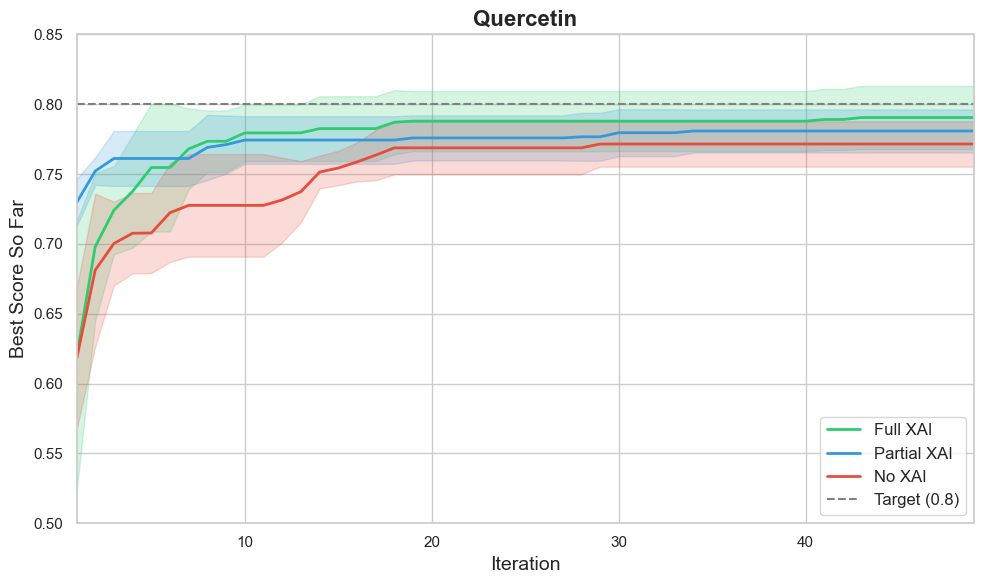

In [7]:
fig1, ax1 = plot_optimization_curves(
    relevant_data,
    title="Quercetin",
    target_score=0.8
)
plt.show()

## Plot 2: Weird Cyclodecane Optimization

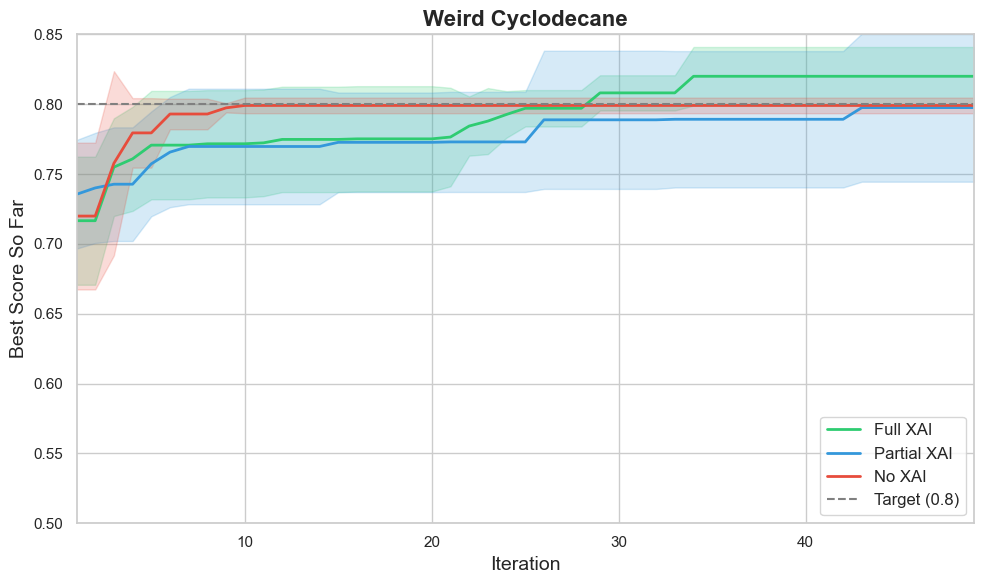

In [8]:
fig2, ax2 = plot_optimization_curves(
    random_data,
    title="Weird Cyclodecane",
    target_score=0.8
)
plt.show()

## Summary Statistics

In [9]:
def compute_summary_stats(data: dict[str, list[list[float]]]) -> pd.DataFrame:
    """Compute summary statistics for each XAI mode."""
    rows = []
    
    for xai_name, trajectories in data.items():
        if not trajectories:
            continue
        
        final_scores = [t[-1] for t in trajectories]
        iterations_to_complete = [len(t) for t in trajectories]
        
        rows.append({
            "XAI Mode": xai_name,
            "Repetitions": len(trajectories),
            "Final Score (mean ± std)": f"{np.mean(final_scores):.3f} ± {np.std(final_scores):.3f}",
            "Final Score (min)": f"{np.min(final_scores):.3f}",
            "Final Score (max)": f"{np.max(final_scores):.3f}",
            "Iterations (mean ± std)": f"{np.mean(iterations_to_complete):.1f} ± {np.std(iterations_to_complete):.1f}",
        })
    
    return pd.DataFrame(rows)

print("Summary Statistics - Quercetin:")
display(compute_summary_stats(relevant_data))

print("\nSummary Statistics - Weird Cyclodecane:")
display(compute_summary_stats(random_data))

Summary Statistics - Quercetin:


,XAI Mode,Repetitions,Final Score (mean ± std),Final Score (min),Final Score (max),Iterations (mean ± std)
0,Full XAI,5,0.790 ± 0.023,0.746,0.810,37.4 ± 12.1
1,Partial XAI,5,0.781 ± 0.016,0.761,0.800,44.0 ± 4.6
2,No XAI,5,0.771 ± 0.017,0.748,0.792,44.8 ± 2.6



Summary Statistics - Weird Cyclodecane:


,XAI Mode,Repetitions,Final Score (mean ± std),Final Score (min),Final Score (max),Iterations (mean ± std)
0,Full XAI,5,0.820 ± 0.021,0.793,0.856,27.2 ± 14.5
1,Partial XAI,5,0.798 ± 0.054,0.704,0.859,43.0 ± 8.8
2,No XAI,5,0.799 ± 0.006,0.793,0.809,38.8 ± 14.5


## Optimization Trajectory: QED vs Similarity

Scatter plots showing all evaluated molecules in the QED-Similarity space. Color indicates iteration number (darker = earlier, lighter = later).

In [10]:
def load_all_trace_data(results_dir: Path, molecule_type: str) -> dict[str, list[dict]]:
    """
    Load all trace entries for a given molecule type.
    
    Returns a dict mapping XAI mode to list of all trace entries (pooled from all repetitions).
    Each entry contains: iteration, smiles, score, scores (with Similarity and QED).
    """
    data = {}
    
    for xai_folder, xai_name in XAI_MODES.items():
        folder_path = results_dir / molecule_type / xai_folder
        all_entries = []
        
        if folder_path.exists():
            json_files = sorted(folder_path.glob("*.json"))
            for json_file in json_files:
                exp_data = load_experiment_data(json_file)
                all_entries.extend(exp_data['trace'])
        
        data[xai_name] = all_entries
    
    return data


def plot_qed_similarity_scatter(data: dict[str, list[dict]], title: str, min_similarity: float = 0.7, min_qed: float = 0.7):
    """
    Plot scatter plots of QED vs Similarity for each XAI mode.
    Color indicates iteration number.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    xai_modes = ["Full XAI", "Partial XAI", "No XAI"]
    
    for ax, xai_name in zip(axes, xai_modes):
        entries = data.get(xai_name, [])
        if not entries:
            ax.set_title(f"{xai_name}\n(No data)")
            continue
        
        # Extract QED, Similarity, and iteration
        qed_vals = [e['scores']['QED'] for e in entries]
        sim_vals = [e['scores']['Similarity'] for e in entries]
        iterations = [e['iteration'] for e in entries]
        
        # Create scatter plot
        scatter = ax.scatter(qed_vals, sim_vals, c=iterations, cmap='viridis_r', 
                            alpha=0.7, s=15, edgecolors='none')
        
        # Add threshold lines
        ax.axvline(x=min_qed, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Min QED ({min_qed})')
        ax.axhline(y=min_similarity, color='blue', linestyle='--', linewidth=1, alpha=0.7, label=f'Min Sim ({min_similarity})')
        
        # Shade the "success" region
        ax.axvspan(min_qed, 1.0, ymin=(min_similarity - 0) / 1.0, ymax=1.0, alpha=0.1, color='green')
        
        ax.set_xlabel('QED', fontsize=12)
        ax.set_ylabel('Similarity', fontsize=12)
        ax.set_title(f"{xai_name}\n({len(entries)} points)", fontsize=12, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal')
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Iteration', fontsize=10)
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig, axes

In [11]:
# Load trace data for both molecule types
quercetin_trace = load_all_trace_data(RESULTS_DIR, "relevant_molecule")
cyclodecane_trace = load_all_trace_data(RESULTS_DIR, "random_molecule")

print("Quercetin trace entries per XAI mode:")
for mode, entries in quercetin_trace.items():
    print(f"  {mode}: {len(entries)} entries")

print("\nWeird Cyclodecane trace entries per XAI mode:")
for mode, entries in cyclodecane_trace.items():
    print(f"  {mode}: {len(entries)} entries")

Quercetin trace entries per XAI mode:
  Full XAI: 187 entries
  Partial XAI: 220 entries
  No XAI: 224 entries

Weird Cyclodecane trace entries per XAI mode:
  Full XAI: 136 entries
  Partial XAI: 215 entries
  No XAI: 194 entries


### Quercetin: QED vs Similarity Trajectory

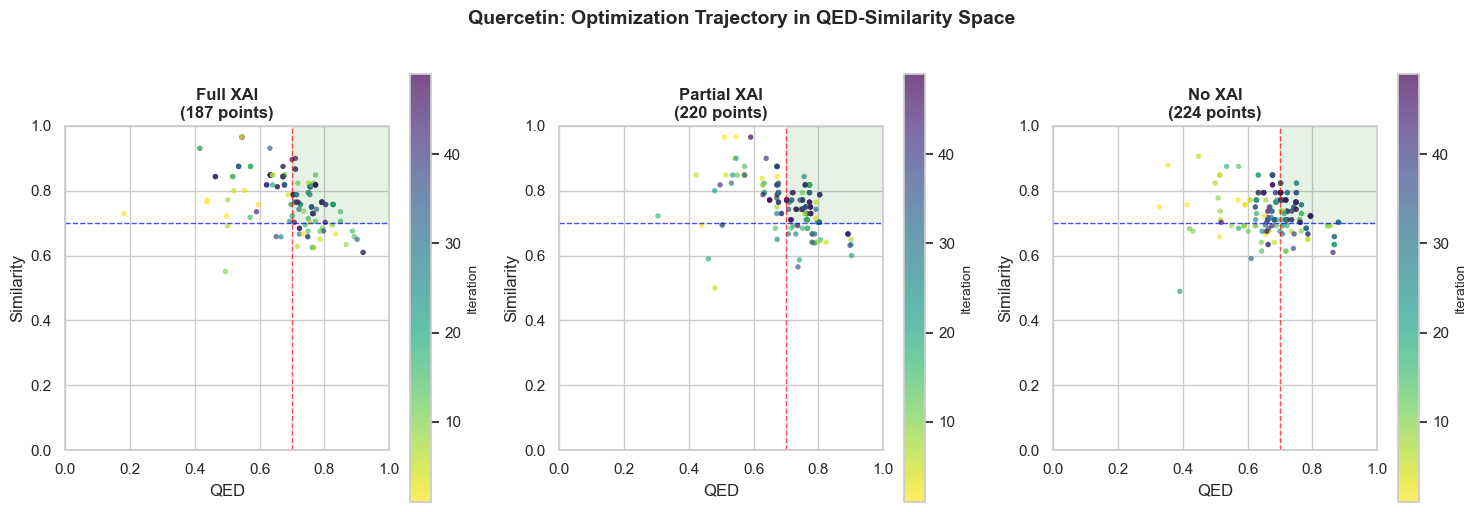

In [12]:
fig3, axes3 = plot_qed_similarity_scatter(
    quercetin_trace,
    title="Quercetin: Optimization Trajectory in QED-Similarity Space"
)
plt.show()

### Weird Cyclodecane: QED vs Similarity Trajectory

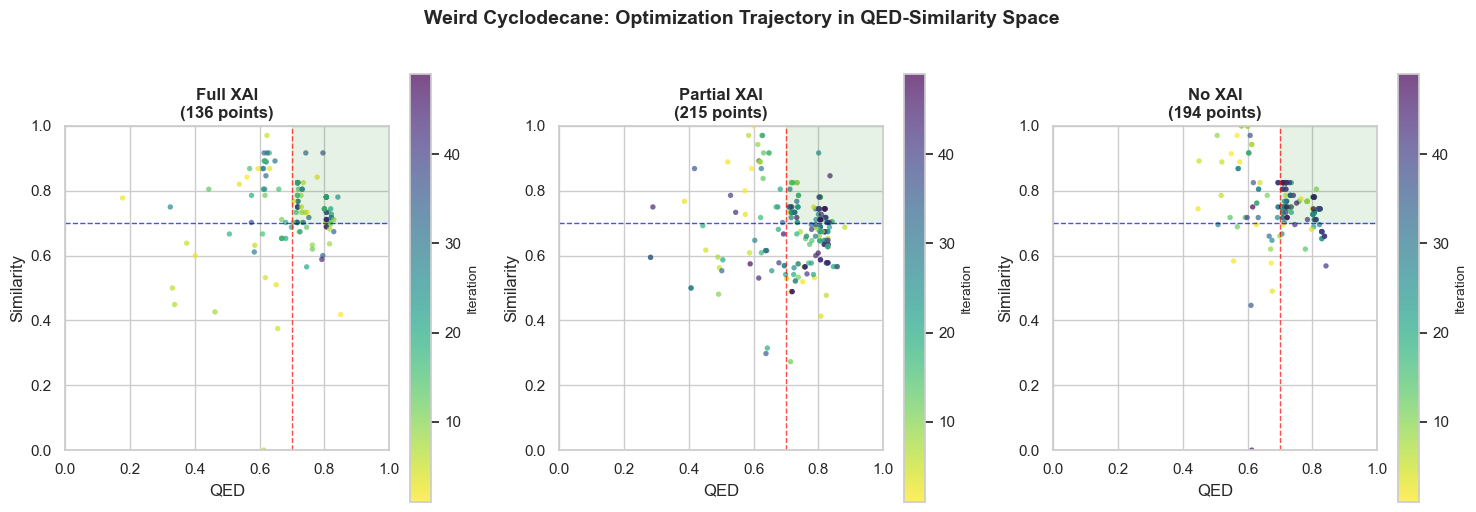

In [13]:
fig4, axes4 = plot_qed_similarity_scatter(
    cyclodecane_trace,
    title="Weird Cyclodecane: Optimization Trajectory in QED-Similarity Space"
)
plt.show()

## Molecule Visualization

Visualize the target molecules and the best optimized molecules found across all runs.

In [14]:
from rdkit import Chem
from rdkit.Chem import Draw, QED
from IPython.display import display

def find_best_molecule(results_dir: Path, molecule_type: str) -> dict:
    """Find the molecule with the highest score across all XAI modes and repetitions."""
    best_entry = None
    best_score = float('-inf')
    best_xai_mode = None
    best_rep = None
    
    for xai_folder, xai_name in XAI_MODES.items():
        folder_path = results_dir / molecule_type / xai_folder
        
        if folder_path.exists():
            json_files = sorted(folder_path.glob("*.json"))
            for json_file in json_files:
                exp_data = load_experiment_data(json_file)
                for entry in exp_data['trace']:
                    if entry['score'] > best_score:
                        best_score = entry['score']
                        best_entry = entry
                        best_xai_mode = xai_name
                        best_rep = json_file.stem
    
    return {
        'entry': best_entry,
        'xai_mode': best_xai_mode,
        'rep': best_rep
    }


def display_molecule_comparison(target_smiles: str, target_name: str, best_info: dict):
    """Display target molecule and best optimized molecule side by side."""
    best_entry = best_info['entry']
    best_smiles = best_entry['smiles']
    best_score = best_entry['score']
    best_scores = best_entry.get('scores', {})
    
    # Create molecule objects
    target_mol = Chem.MolFromSmiles(target_smiles)
    best_mol = Chem.MolFromSmiles(best_smiles)
    
    # Calculate QED for target molecule
    target_qed = QED.qed(target_mol)
    
    # Create images
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Target molecule
    target_img = Draw.MolToImage(target_mol, size=(400, 400))
    axes[0].imshow(target_img)
    axes[0].axis('off')
    axes[0].set_title(f"Target: {target_name}\nQED: {target_qed:.3f}", fontsize=14, fontweight='bold')
    
    # Best molecule
    best_img = Draw.MolToImage(best_mol, size=(400, 400))
    axes[1].imshow(best_img)
    axes[1].axis('off')
    
    # Build score string
    score_parts = [f"Score: {best_score:.3f}"]
    for name, val in best_scores.items():
        score_parts.append(f"{name}: {val:.3f}")
    score_str = " | ".join(score_parts)
    
    axes[1].set_title(f"Best Optimized ({best_info['xai_mode']})\n{score_str}", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Target SMILES: {target_smiles}")
    print(f"Best SMILES:   {best_smiles}")
    print(f"Found in: {best_info['xai_mode']}, {best_info['rep']}")

### Quercetin: Target vs Best Optimized Molecule

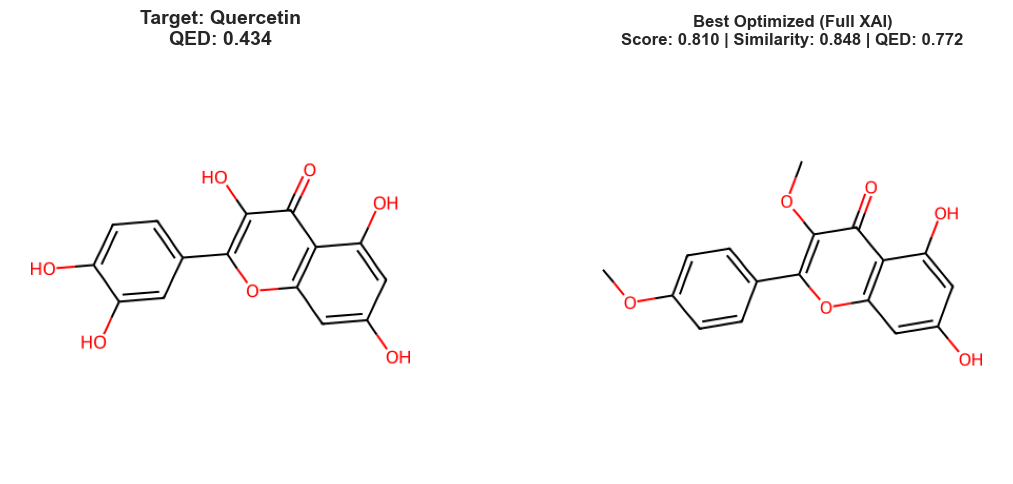

Target SMILES: O=C1c3c(O/C(=C1/O)c2ccc(O)c(O)c2)cc(O)cc3O
Best SMILES:   O=C1c2c(O/C(=C1/OC)c3ccc(OC)cc3)cc(O)cc2O
Found in: Full XAI, sim_qed_relevant_full_rep2_conversation_20251208_114950


In [15]:
# Quercetin target SMILES
QUERCETIN_SMILES = "O=C1c3c(O/C(=C1/O)c2ccc(O)c(O)c2)cc(O)cc3O"

# Find best molecule for Quercetin experiments
quercetin_best = find_best_molecule(RESULTS_DIR, "relevant_molecule")

# Display comparison
display_molecule_comparison(QUERCETIN_SMILES, "Quercetin", quercetin_best)

### Weird Cyclodecane: Target vs Best Optimized Molecule

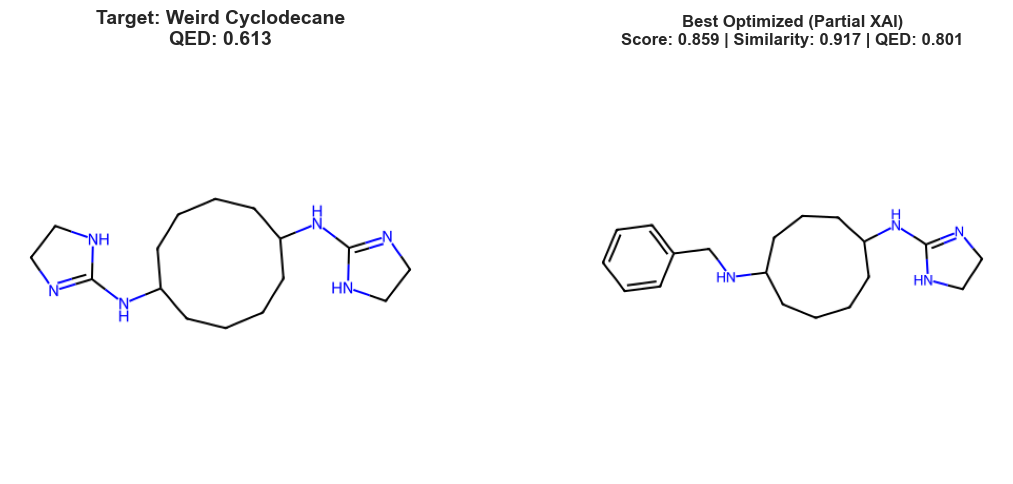

Target SMILES: C1CCC(CCCCC(C1)NC2=NCCN2)NC3=NCCN3
Best SMILES:   C1CCC(CCCC(C1)NCC2=CC=CC=C2)NC3=NCCN3
Found in: Partial XAI, sim_qed_random_partial_rep4_conversation_20251208_124324


In [16]:
# Weird Cyclodecane target SMILES
CYCLODECANE_SMILES = "C1CCC(CCCCC(C1)NC2=NCCN2)NC3=NCCN3"

# Find best molecule for Weird Cyclodecane experiments
cyclodecane_best = find_best_molecule(RESULTS_DIR, "random_molecule")

# Display comparison
display_molecule_comparison(CYCLODECANE_SMILES, "Weird Cyclodecane", cyclodecane_best)

---

# IC50 Experiments Analysis

Analysis of IC50 optimization experiments with different XAI settings.

In [17]:
# Define paths for IC50 experiments
IC50_RESULTS_DIR = Path("../data/results/ic50mpro")
IC50_QED_RESULTS_DIR = Path("../data/results/ic50mpro_qed")

# XAI modes for ic50mpro (only full and none)
XAI_MODES_IC50 = {
    "full_xai": "Full XAI",
    "no_xai": "No XAI"
}

# XAI modes for ic50mpro_qed (full, partial, none)
XAI_MODES_IC50_QED = {
    "full_xai": "Full XAI",
    "partial_xai": "Partial XAI",
    "no_xai": "No XAI"
}

In [18]:
def extract_best_ic50_trajectory(trace: list[dict]) -> list[float]:
    """Extract the best (minimum) IC50 so far at each iteration from the trace."""
    best_ic50s = []
    best_so_far = float('inf')  # Lower is better
    
    for entry in trace:
        scores = entry.get('scores', {})
        ic50 = scores.get('IC50', entry.get('score', float('inf')))
        best_so_far = min(best_so_far, ic50)
        best_ic50s.append(best_so_far)
    
    return best_ic50s


def load_ic50_experiments(results_dir: Path, xai_modes: dict) -> dict[str, list[list[float]]]:
    """
    Load IC50 experiments (no molecule type subdirectory).
    Returns a dict mapping XAI mode to list of best (minimum) IC50 trajectories.
    """
    data = {}
    
    for xai_folder, xai_name in xai_modes.items():
        folder_path = results_dir / xai_folder
        trajectories = []
        
        if folder_path.exists():
            json_files = sorted(folder_path.glob("*.json"))
            for json_file in json_files:
                exp_data = load_experiment_data(json_file)
                trajectory = extract_best_ic50_trajectory(exp_data['trace'])
                trajectories.append(trajectory)
        
        data[xai_name] = trajectories
    
    return data


def load_ic50_trace_data(results_dir: Path, xai_modes: dict) -> dict[str, list[dict]]:
    """
    Load all trace entries for IC50 experiments.
    Returns a dict mapping XAI mode to list of all trace entries.
    """
    data = {}
    
    for xai_folder, xai_name in xai_modes.items():
        folder_path = results_dir / xai_folder
        all_entries = []
        
        if folder_path.exists():
            json_files = sorted(folder_path.glob("*.json"))
            for json_file in json_files:
                exp_data = load_experiment_data(json_file)
                all_entries.extend(exp_data['trace'])
        
        data[xai_name] = all_entries
    
    return data

## IC50 Mpro (Novel) - Optimization Curves

Comparing Full XAI vs No XAI for IC50 optimization.

In [19]:
# Load IC50 Mpro data
ic50_data = load_ic50_experiments(IC50_RESULTS_DIR, XAI_MODES_IC50)

print("IC50 Mpro Experiments:")
for mode, trajectories in ic50_data.items():
    if trajectories:
        lengths = [len(t) for t in trajectories]
        print(f"  {mode}: {len(trajectories)} runs, iterations: {lengths}")

IC50 Mpro Experiments:
  Full XAI: 5 runs, iterations: [12, 4, 3, 5, 27]
  No XAI: 5 runs, iterations: [13, 2, 5, 1, 1]


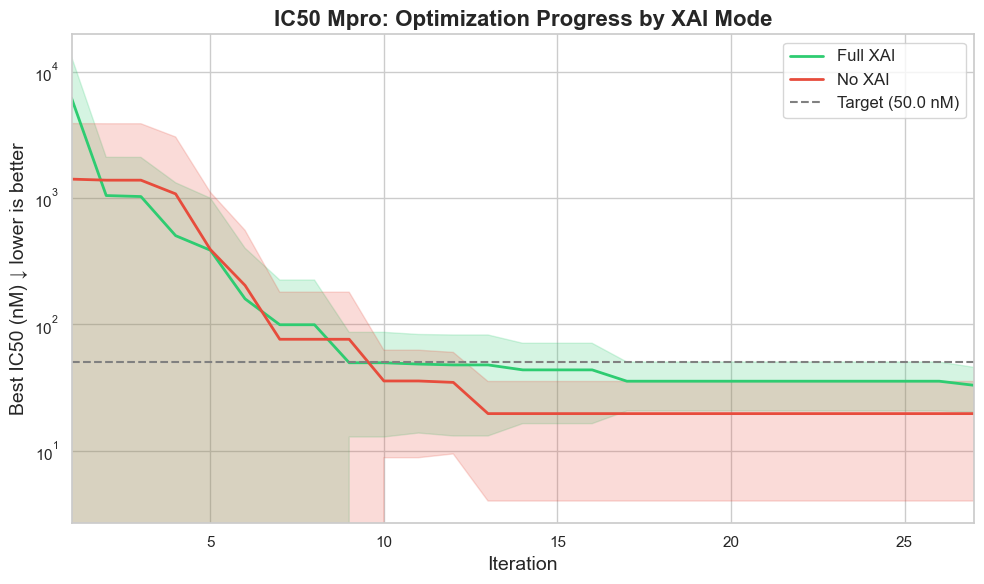

In [20]:
def plot_optimization_curves_ic50(
    data: dict[str, list[list[float]]],
    title: str,
    target_ic50: float = None,
    max_iterations: int = None,
    xai_modes_order: list[str] = None
):
    """
    Plot optimization curves for IC50 experiments.
    Lower IC50 is better, y-axis uses log scale.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = {
        "Full XAI": "#2ecc71",      # Green
        "Partial XAI": "#3498db",   # Blue
        "No XAI": "#e74c3c"         # Red
    }
    
    if xai_modes_order is None:
        xai_modes_order = list(data.keys())
    
    # Find global max iterations for consistent x-axis
    if max_iterations is None:
        max_iterations = max(
            max(len(t) for t in trajectories) 
            for trajectories in data.values() 
            if trajectories
        )
    
    for xai_name in xai_modes_order:
        trajectories = data.get(xai_name, [])
        if not trajectories:
            continue
            
        iterations, mean, ci = compute_stats(trajectories, max_iterations)
        
        color = colors.get(xai_name, "#333333")
        ax.plot(iterations, mean, label=xai_name, color=color, linewidth=2)
        ax.fill_between(iterations, mean - ci, mean + ci, color=color, alpha=0.2)
    
    # Add target IC50 line if provided
    if target_ic50 is not None:
        ax.axhline(y=target_ic50, color='gray', linestyle='--', linewidth=1.5, label=f'Target ({target_ic50} nM)')
    
    ax.set_xlabel('Iteration', fontsize=14)
    ax.set_ylabel('Best IC50 (nM) ↓ lower is better', fontsize=14)
    ax.set_yscale('log')  # Log scale for IC50
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.legend(loc='upper right', fontsize=12)  # Upper right since lower is better
    ax.set_xlim(1, max_iterations)
    
    plt.tight_layout()
    return fig, ax


# Plot IC50 Mpro optimization curves
fig_ic50, ax_ic50 = plot_optimization_curves_ic50(
    ic50_data,
    title="IC50 Mpro: Optimization Progress by XAI Mode",
    target_ic50=50.0,  # Target from the script
    xai_modes_order=["Full XAI", "No XAI"]
)
plt.show()

## IC50 Mpro + QED (Novel) - Optimization Curves

Comparing Full XAI, Partial XAI, and No XAI for IC50 + QED optimization.

In [21]:
# Load IC50 + QED data
ic50_qed_data = load_ic50_experiments(IC50_QED_RESULTS_DIR, XAI_MODES_IC50_QED)

print("IC50 Mpro + QED Experiments:")
for mode, trajectories in ic50_qed_data.items():
    if trajectories:
        lengths = [len(t) for t in trajectories]
        print(f"  {mode}: {len(trajectories)} runs, iterations: {lengths}")

IC50 Mpro + QED Experiments:
  Full XAI: 5 runs, iterations: [7, 10, 42, 44, 13]
  Partial XAI: 5 runs, iterations: [45, 14, 48, 14, 9]
  No XAI: 5 runs, iterations: [14, 1, 29, 32, 30]


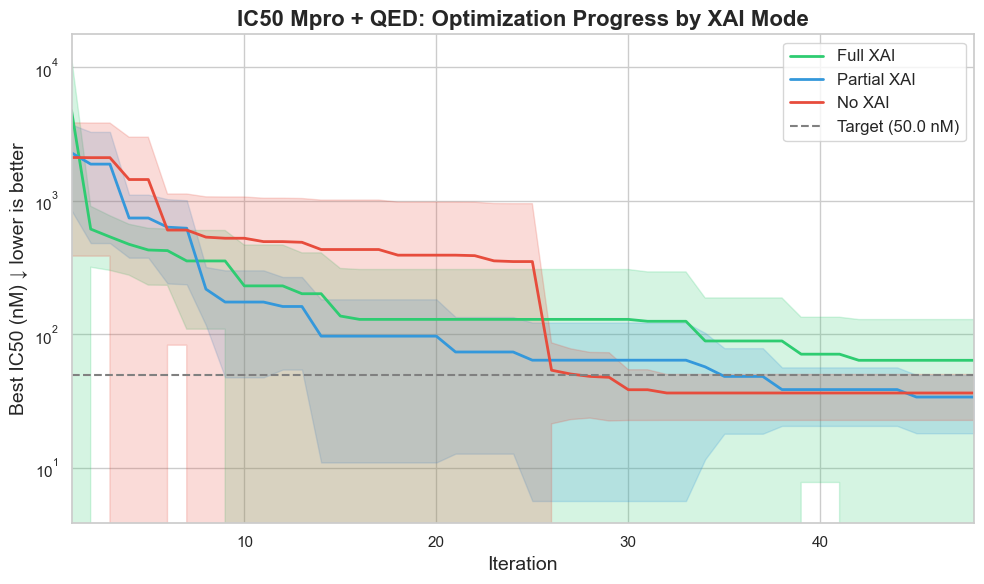

In [22]:
# Plot IC50 + QED optimization curves
fig_ic50_qed, ax_ic50_qed = plot_optimization_curves_ic50(
    ic50_qed_data,
    title="IC50 Mpro + QED: Optimization Progress by XAI Mode",
    target_ic50=50.0,  # Target from the script
    xai_modes_order=["Full XAI", "Partial XAI", "No XAI"]
)
plt.show()

## IC50 Mpro + QED: Optimization Trajectory (IC50 vs QED)

Scatter plots showing all evaluated molecules in the IC50-QED space. Color indicates iteration number.

In [23]:
def plot_ic50_qed_scatter(data: dict[str, list[dict]], title: str, min_qed: float = 0.5, target_ic50: float = 50.0):
    """
    Plot scatter plots of QED vs IC50 for each XAI mode.
    Color indicates iteration number.
    IC50 y-axis uses log scale (lower IC50 is better).
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    xai_modes = ["Full XAI", "Partial XAI", "No XAI"]
    
    for ax, xai_name in zip(axes, xai_modes):
        entries = data.get(xai_name, [])
        if not entries:
            ax.set_title(f"{xai_name}\n(No data)")
            continue
        
        # Extract IC50, QED, and iteration
        sample_scores = entries[0].get('scores', {})
        ic50_key = 'IC50' if 'IC50' in sample_scores else list(sample_scores.keys())[0]
        
        ic50_vals = [e['scores'].get(ic50_key, e['score']) for e in entries]
        qed_vals = [e['scores'].get('QED', 0) for e in entries]
        iterations = [e['iteration'] for e in entries]
        
        # Create scatter plot
        scatter = ax.scatter(qed_vals, ic50_vals, c=iterations, cmap='viridis_r', 
                            alpha=0.7, s=15, edgecolors='none')
        
        # Add threshold lines
        ax.axvline(x=min_qed, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Min QED ({min_qed})')
        ax.axhline(y=target_ic50, color='blue', linestyle='--', linewidth=1, alpha=0.7, label=f'Target IC50 ({target_ic50} nM)')
        
        ax.set_xlabel('QED', fontsize=12)
        ax.set_ylabel('IC50 (nM) ↓ lower is better', fontsize=12)
        ax.set_yscale('log')  # Log scale for IC50
        ax.set_title(f"{xai_name}\n({len(entries)} points)", fontsize=12, fontweight='bold')
        ax.set_xlim(0, 1)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Iteration', fontsize=10)
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig, axes

In [24]:
# Load trace data for IC50 + QED experiments
ic50_qed_trace = load_ic50_trace_data(IC50_QED_RESULTS_DIR, XAI_MODES_IC50_QED)

print("IC50 + QED trace entries per XAI mode:")
for mode, entries in ic50_qed_trace.items():
    print(f"  {mode}: {len(entries)} entries")

IC50 + QED trace entries per XAI mode:
  Full XAI: 116 entries
  Partial XAI: 130 entries
  No XAI: 106 entries


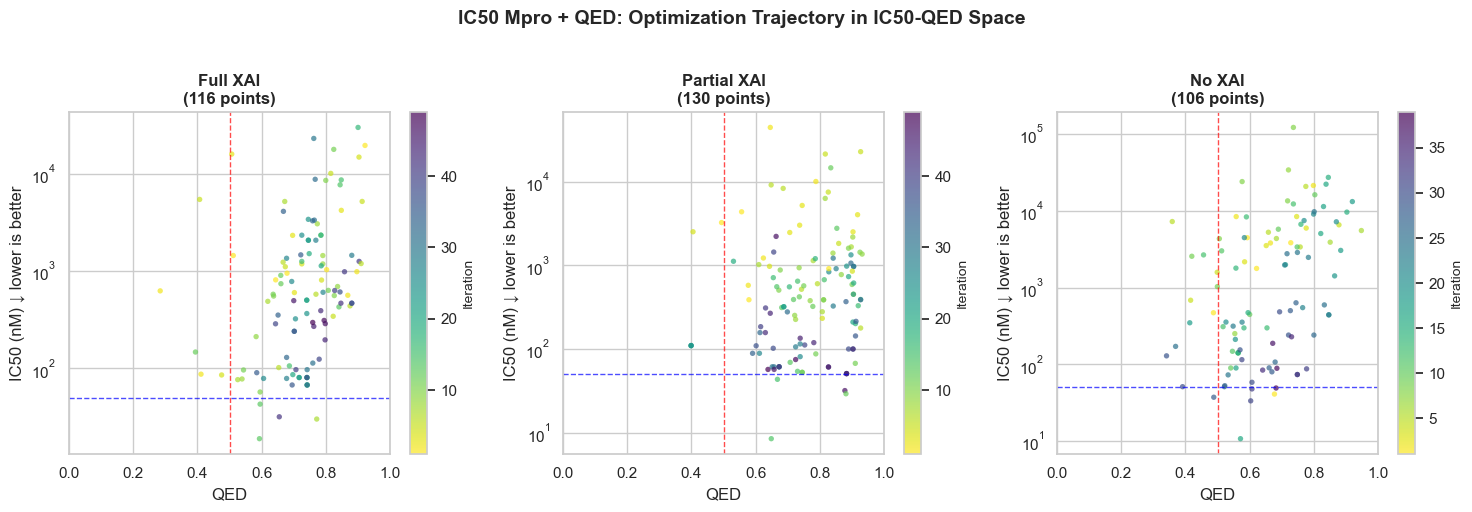

In [25]:
# Plot IC50 vs QED scatter
fig_ic50_qed_scatter, axes_ic50_qed_scatter = plot_ic50_qed_scatter(
    ic50_qed_trace,
    title="IC50 Mpro + QED: Optimization Trajectory in IC50-QED Space",
    min_qed=0.5,
    target_ic50=50.0
)
plt.show()

## IC50 Experiments - Summary Statistics

In [26]:
print("Summary Statistics - IC50 Mpro:")
display(compute_summary_stats(ic50_data))

print("\nSummary Statistics - IC50 Mpro + QED:")
display(compute_summary_stats(ic50_qed_data))

Summary Statistics - IC50 Mpro:


,XAI Mode,Repetitions,Final Score (mean ± std),Final Score (min),Final Score (max),Iterations (mean ± std)
0,Full XAI,5,32.871 ± 12.991,10.135,47.751,10.2 ± 9.0
1,No XAI,5,19.606 ± 15.946,3.136,40.314,4.4 ± 4.5



Summary Statistics - IC50 Mpro + QED:


,XAI Mode,Repetitions,Final Score (mean ± std),Final Score (min),Final Score (max),Iterations (mean ± std)
0,Full XAI,5,63.920 ± 66.528,18.888,196.109,23.2 ± 16.3
1,Partial XAI,5,33.922 ± 16.090,8.447,56.924,26.0 ± 16.9
2,No XAI,5,36.368 ± 13.983,10.730,49.072,21.2 ± 12.0


## IC50 Mpro + QED: Best Molecules (QED > threshold)

Display the best molecule (highest IC50) for each XAI mode, considering only molecules with QED above the threshold.

In [27]:
from rdkit import Chem
from rdkit.Chem import Draw

def find_best_ic50_molecule_constrained(trace_data: dict[str, list[dict]], qed_threshold: float = 0.5) -> dict[str, dict]:
    """
    Find the best molecule (lowest IC50 = best) for each XAI mode where QED > threshold.
    
    Returns a dict mapping XAI mode to the best entry (or None if no valid molecule found).
    """
    best_molecules = {}
    
    for xai_name, entries in trace_data.items():
        best_entry = None
        best_ic50 = float('inf')  # Lower is better
        
        for entry in entries:
            scores = entry.get('scores', {})
            qed = scores.get('QED', 0)
            ic50 = scores.get('IC50', entry.get('score', 0))
            
            if qed >= qed_threshold and ic50 < best_ic50:  # Lower IC50 is better
                best_ic50 = ic50
                best_entry = entry
        
        best_molecules[xai_name] = best_entry
    
    return best_molecules


def display_best_ic50_molecules(best_molecules: dict[str, dict], qed_threshold: float = 0.5):
    """Display the best IC50 molecules for each XAI mode."""
    xai_modes = ["Full XAI", "Partial XAI", "No XAI"]
    valid_modes = [m for m in xai_modes if best_molecules.get(m) is not None]
    
    if not valid_modes:
        print("No molecules found with QED above threshold.")
        return
    
    fig, axes = plt.subplots(1, len(valid_modes), figsize=(5 * len(valid_modes), 5))
    if len(valid_modes) == 1:
        axes = [axes]
    
    for ax, xai_name in zip(axes, valid_modes):
        entry = best_molecules[xai_name]
        smiles = entry['smiles']
        scores = entry.get('scores', {})
        ic50 = scores.get('IC50', entry.get('score', 0))
        qed = scores.get('QED', 0)
        
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            img = Draw.MolToImage(mol, size=(400, 400))
            ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"{xai_name}\nIC50: {ic50:.3f} | QED: {qed:.3f}", fontsize=12, fontweight='bold')
    
    fig.suptitle(f"Best IC50 Molecules (QED ≥ {qed_threshold})", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print SMILES
    print(f"\nBest molecules with QED ≥ {qed_threshold}:")
    for xai_name in valid_modes:
        entry = best_molecules[xai_name]
        scores = entry.get('scores', {})
        print(f"  {xai_name}: {entry['smiles']}")
        print(f"    IC50: {scores.get('IC50', 'N/A'):.3f}, QED: {scores.get('QED', 'N/A'):.3f}")

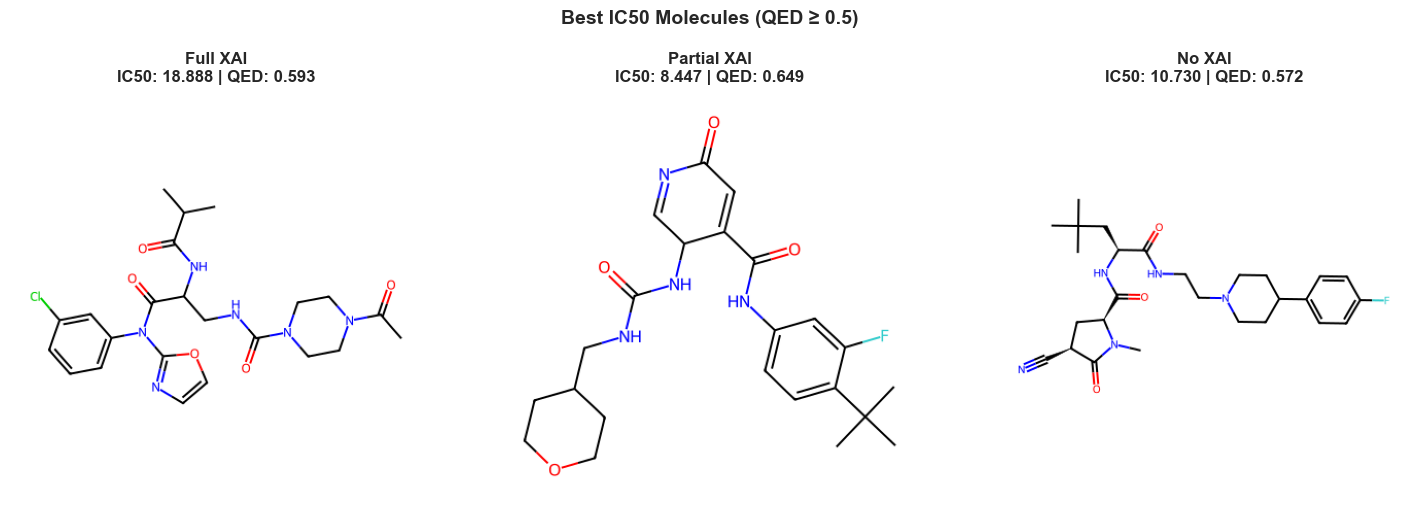


Best molecules with QED ≥ 0.5:
  Full XAI: CC(C)C(=O)NC(CNC(=O)N1CCN(CC1)C(=O)C)C(=O)N(C1=CC=CC(Cl)=C1)C2=NC=CO2
    IC50: 18.888, QED: 0.593
  Partial XAI: CC(C)(C)C1=CC=C(C=C1F)NC(=O)C2=CC(=O)N=CC2NC(=O)NCC3CCOCC3
    IC50: 8.447, QED: 0.649
  No XAI: CC(C)(C)C[C@H](NC(=O)[C@@H]1C[C@@H](C(=O)N1C)C#N)C(=O)NCCN2CCC(CC2)C3=CC=C(C=C3)F
    IC50: 10.730, QED: 0.572


In [28]:
QED_THRESHOLD = 0.5

# Find best IC50 molecules with QED constraint
best_ic50_constrained = find_best_ic50_molecule_constrained(ic50_qed_trace, qed_threshold=QED_THRESHOLD)

# Display them
display_best_ic50_molecules(best_ic50_constrained, qed_threshold=QED_THRESHOLD)

## IC50 Mpro + QED: Constrained Optimization Curve

Best IC50 score over iterations, only considering molecules where QED ≥ threshold.

In [29]:
def load_ic50_constrained_trajectories(
    results_dir: Path, 
    xai_modes: dict, 
    qed_threshold: float = 0.5
) -> dict[str, list[list[float]]]:
    """
    Load IC50 trajectories where only molecules with QED >= threshold are considered.
    Tracks MINIMUM IC50 (lower is better).
    
    Returns a dict mapping XAI mode to list of constrained best-IC50 trajectories.
    """
    data = {}
    
    for xai_folder, xai_name in xai_modes.items():
        folder_path = results_dir / xai_folder
        trajectories = []
        
        if folder_path.exists():
            json_files = sorted(folder_path.glob("*.json"))
            for json_file in json_files:
                exp_data = load_experiment_data(json_file)
                trace = exp_data['trace']
                
                # Build constrained trajectory
                best_ic50_so_far = float('inf')  # Lower is better
                trajectory = []
                
                for entry in trace:
                    scores = entry.get('scores', {})
                    qed = scores.get('QED', 0)
                    ic50 = scores.get('IC50', entry.get('score', 0))
                    
                    # Only update best if QED meets threshold (lower IC50 is better)
                    if qed >= qed_threshold:
                        best_ic50_so_far = min(best_ic50_so_far, ic50)
                    
                    # Record current best (may be inf if no valid molecule yet)
                    if best_ic50_so_far < float('inf'):
                        trajectory.append(best_ic50_so_far)
                    else:
                        trajectory.append(np.nan)  # No valid molecule yet
                
                trajectories.append(trajectory)
        
        data[xai_name] = trajectories
    
    return data


def plot_constrained_ic50_curves(
    data: dict[str, list[list[float]]],
    title: str,
    qed_threshold: float = 0.5,
    target_ic50: float = None,
    max_iterations: int = None
):
    """
    Plot constrained IC50 optimization curves (only QED >= threshold molecules).
    Lower IC50 is better, y-axis uses log scale.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = {
        "Full XAI": "#2ecc71",
        "Partial XAI": "#3498db",
        "No XAI": "#e74c3c"
    }
    
    if max_iterations is None:
        max_iterations = max(
            max(len(t) for t in trajectories) 
            for trajectories in data.values() 
            if trajectories
        )
    
    for xai_name in ["Full XAI", "Partial XAI", "No XAI"]:
        trajectories = data.get(xai_name, [])
        if not trajectories:
            continue
        
        # Handle NaN values - compute stats ignoring NaN
        # Pad trajectories to same length
        padded = []
        for t in trajectories:
            if len(t) < max_iterations:
                padded.append(t + [t[-1] if t and not np.isnan(t[-1]) else np.nan] * (max_iterations - len(t)))
            else:
                padded.append(t[:max_iterations])
        
        arr = np.array(padded)
        
        # Compute mean and CI ignoring NaN
        with np.errstate(all='ignore'):
            mean = np.nanmean(arr, axis=0)
            std = np.nanstd(arr, axis=0, ddof=1)
            n = np.sum(~np.isnan(arr), axis=0)
            ci = 1.96 * std / np.sqrt(n)
        
        iterations = np.arange(1, max_iterations + 1)
        
        color = colors.get(xai_name, "#333333")
        ax.plot(iterations, mean, label=xai_name, color=color, linewidth=2)
        ax.fill_between(iterations, mean - ci, mean + ci, color=color, alpha=0.2)
    
    # Add target IC50 line if provided
    if target_ic50 is not None:
        ax.axhline(y=target_ic50, color='gray', linestyle='--', linewidth=1.5, label=f'Target ({target_ic50} nM)')
    
    ax.set_xlabel('Iteration', fontsize=14)
    ax.set_ylabel('Best IC50 (nM) ↓ lower is better', fontsize=14)
    ax.set_yscale('log')  # Log scale for IC50
    ax.set_title(f"{title}\n(Only molecules with QED ≥ {qed_threshold})", fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=12)  # Upper right since lower is better
    ax.set_xlim(1, max_iterations)
    
    plt.tight_layout()
    return fig, ax

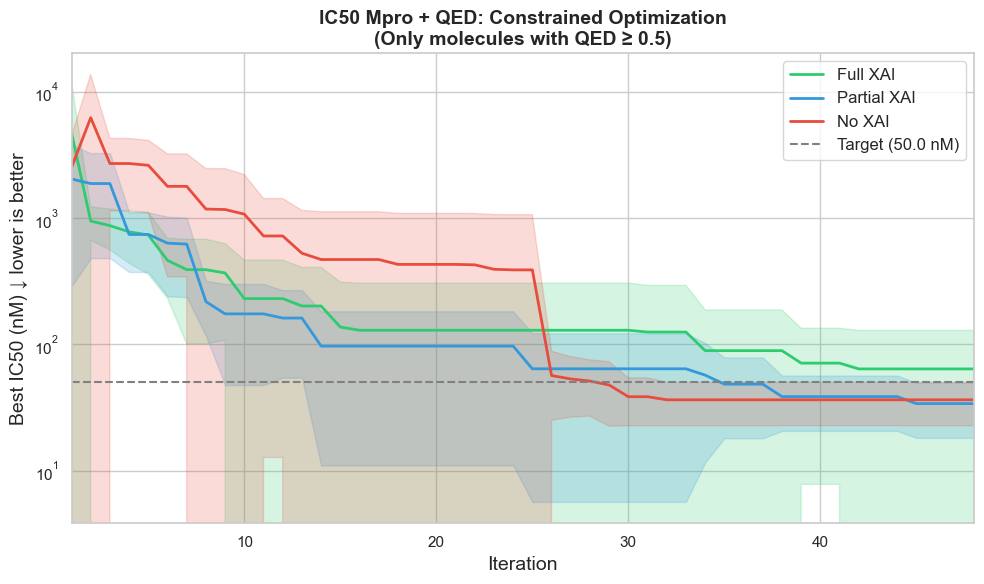

In [30]:
# Load constrained trajectories
ic50_constrained_data = load_ic50_constrained_trajectories(
    IC50_QED_RESULTS_DIR, 
    XAI_MODES_IC50_QED, 
    qed_threshold=QED_THRESHOLD
)

# Plot constrained optimization curves
fig_constrained, ax_constrained = plot_constrained_ic50_curves(
    ic50_constrained_data,
    title="IC50 Mpro + QED: Constrained Optimization",
    qed_threshold=QED_THRESHOLD,
    target_ic50=50.0  # Target from the script
)
plt.show()

---

# Success Molecules Gallery

Display all molecules that successfully met the threshold criteria for each experiment and XAI mode.

In [31]:
from rdkit.Chem import Draw

def find_success_molecules_similarity_qed(
    trace_data: dict[str, list[dict]], 
    min_similarity: float = 0.7, 
    min_qed: float = 0.7,
    target_score: float = 0.8
) -> dict[str, list[dict]]:
    """Find all molecules that meet similarity+QED success criteria."""
    success = {}
    
    for xai_name, entries in trace_data.items():
        successful = []
        
        for entry in entries:
            scores = entry.get('scores', {})
            similarity = scores.get('Similarity', 0)
            qed = scores.get('QED', 0)
            combined = entry.get('score', 0)
            
            if (combined >= target_score and 
                similarity >= min_similarity and 
                qed >= min_qed):
                successful.append(entry)
        
        success[xai_name] = successful
    
    return success


def find_success_molecules_ic50(
    trace_data: dict[str, list[dict]], 
    target_ic50: float = 50.0
) -> dict[str, list[dict]]:
    """Find all molecules that meet IC50 success criteria (IC50 <= target)."""
    success = {}
    
    for xai_name, entries in trace_data.items():
        successful = []
        
        for entry in entries:
            scores = entry.get('scores', {})
            ic50 = scores.get('IC50', float('inf'))
            
            if ic50 <= target_ic50:
                successful.append(entry)
        
        success[xai_name] = successful
    
    return success


def find_success_molecules_ic50_qed(
    trace_data: dict[str, list[dict]], 
    target_ic50: float = 50.0,
    min_qed: float = 0.5
) -> dict[str, list[dict]]:
    """Find all molecules that meet IC50 + QED success criteria."""
    success = {}
    
    for xai_name, entries in trace_data.items():
        successful = []
        
        for entry in entries:
            scores = entry.get('scores', {})
            ic50 = scores.get('IC50', float('inf'))
            qed = scores.get('QED', 0)
            
            if ic50 <= target_ic50 and qed >= min_qed:
                successful.append(entry)
        
        success[xai_name] = successful
    
    return success


def display_success_grid(success_molecules: dict[str, list[dict]], title: str, score_keys: list[str] = None):
    """Display a grid of successful molecules for each XAI mode."""
    xai_modes = ["Full XAI", "Partial XAI", "No XAI"]
    
    for xai_name in xai_modes:
        molecules = success_molecules.get(xai_name, [])
        if not molecules:
            print(f"\n{xai_name}: No successful molecules found")
            continue
        
        print(f"\n{xai_name}: {len(molecules)} successful molecule(s)")
        
        # Create molecule objects and legends
        mols = []
        legends = []
        
        for entry in molecules:
            smiles = entry.get('smiles', '')
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                mols.append(mol)
                
                # Build legend
                scores = entry.get('scores', {})
                if score_keys:
                    legend_parts = []
                    for key in score_keys:
                        if key in scores:
                            legend_parts.append(f"{key}: {scores[key]:.2f}")
                    legends.append("\n".join(legend_parts))
                else:
                    legends.append(f"Score: {entry.get('score', 0):.3f}")
        
        if mols:
            # Display grid
            img = Draw.MolsToGridImage(
                mols, 
                molsPerRow=min(4, len(mols)),
                subImgSize=(250, 250),
                legends=legends
            )
            display(img)

## Similarity + QED: Quercetin - Success Molecules

Molecules with: Combined Score ≥ 0.8, Similarity ≥ 0.7, QED ≥ 0.7

=== Quercetin: Successful Molecules ===

Full XAI: 2 successful molecule(s)


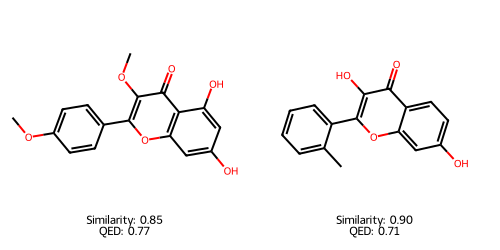


Partial XAI: No successful molecules found

No XAI: No successful molecules found


In [32]:
quercetin_success = find_success_molecules_similarity_qed(
    quercetin_trace,
    min_similarity=0.7,
    min_qed=0.7,
    target_score=0.8
)

print("=== Quercetin: Successful Molecules ===")
display_success_grid(quercetin_success, "Quercetin", score_keys=["Similarity", "QED"])

## Similarity + QED: Weird Cyclodecane - Success Molecules

Molecules with: Combined Score ≥ 0.8, Similarity ≥ 0.7, QED ≥ 0.7

=== Weird Cyclodecane: Successful Molecules ===

Full XAI: 4 successful molecule(s)


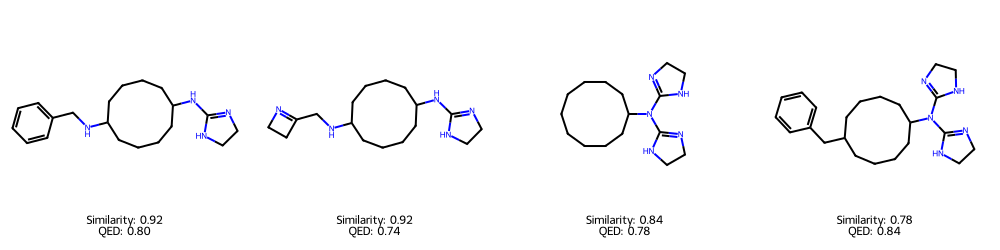


Partial XAI: 2 successful molecule(s)


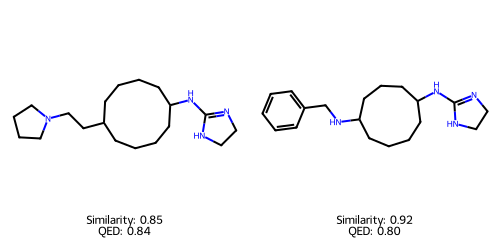


No XAI: 1 successful molecule(s)


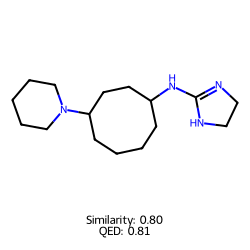

In [33]:
cyclodecane_success = find_success_molecules_similarity_qed(
    cyclodecane_trace,
    min_similarity=0.7,
    min_qed=0.7,
    target_score=0.8
)

print("=== Weird Cyclodecane: Successful Molecules ===")
display_success_grid(cyclodecane_success, "Weird Cyclodecane", score_keys=["Similarity", "QED"])

## IC50 Mpro - Success Molecules

Molecules with: IC50 ≤ 50 nM

=== IC50 Mpro: Successful Molecules ===

Full XAI: 5 successful molecule(s)


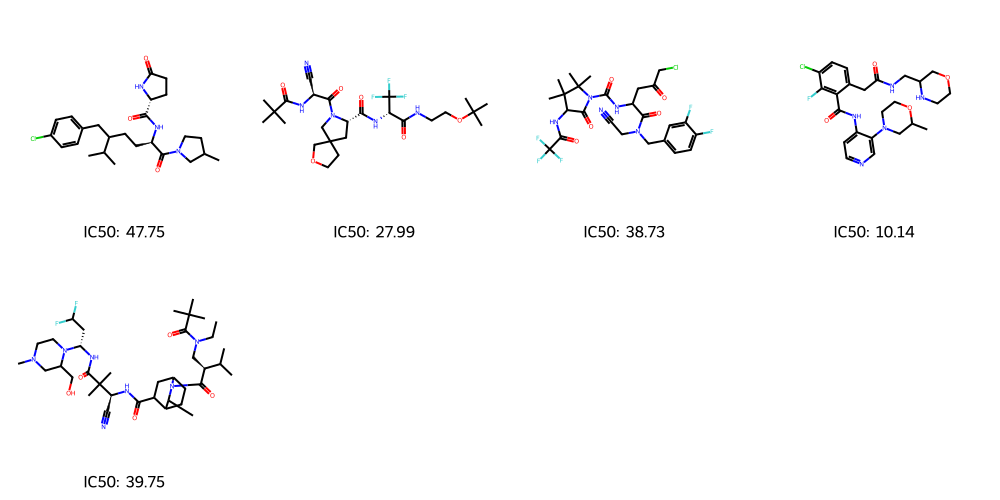


Partial XAI: No successful molecules found

No XAI: 5 successful molecule(s)


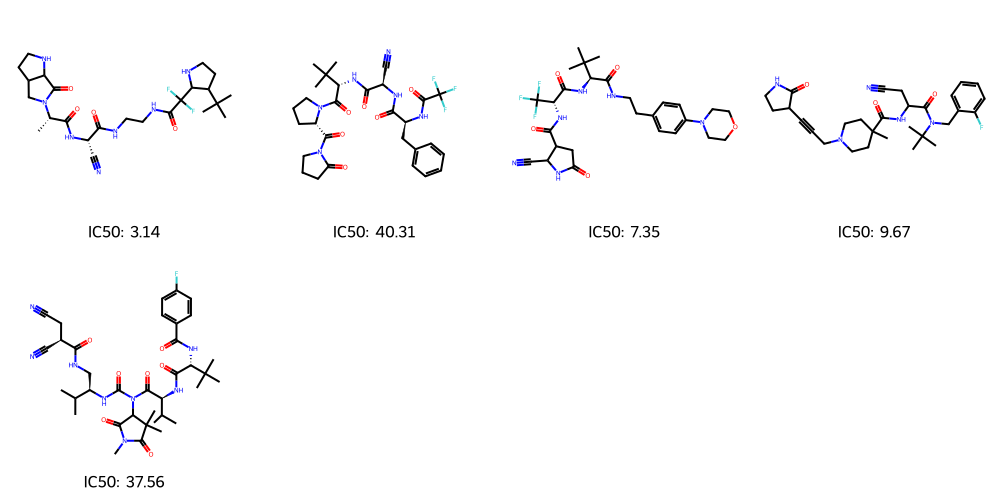

In [34]:
# Load trace data for IC50 Mpro experiments (only full and none)
ic50_trace = load_ic50_trace_data(IC50_RESULTS_DIR, XAI_MODES_IC50)

ic50_success = find_success_molecules_ic50(
    ic50_trace,
    target_ic50=50.0
)

print("=== IC50 Mpro: Successful Molecules ===")
display_success_grid(ic50_success, "IC50 Mpro", score_keys=["IC50"])

## IC50 Mpro + QED - Success Molecules

Molecules with: IC50 ≤ 50 nM AND QED ≥ 0.5

=== IC50 Mpro + QED: Successful Molecules ===

Full XAI: 4 successful molecule(s)


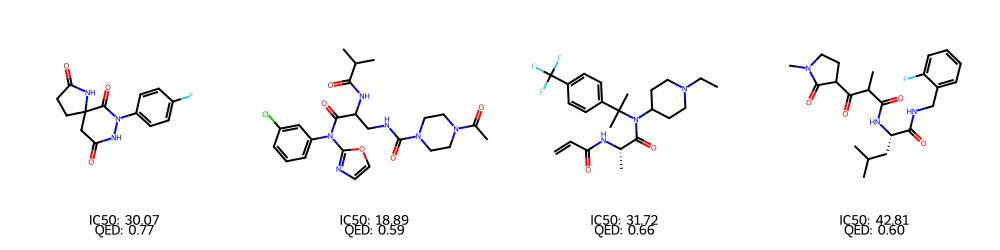


Partial XAI: 4 successful molecule(s)


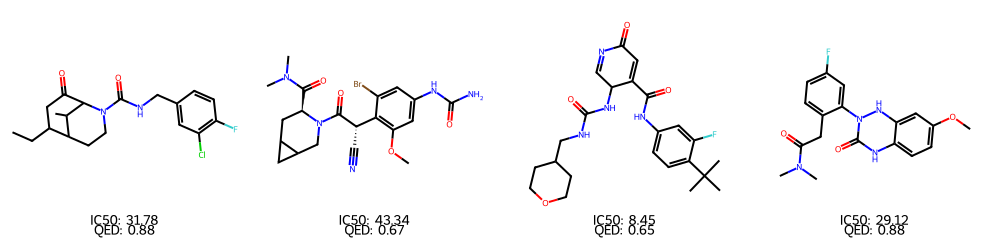


No XAI: 5 successful molecule(s)


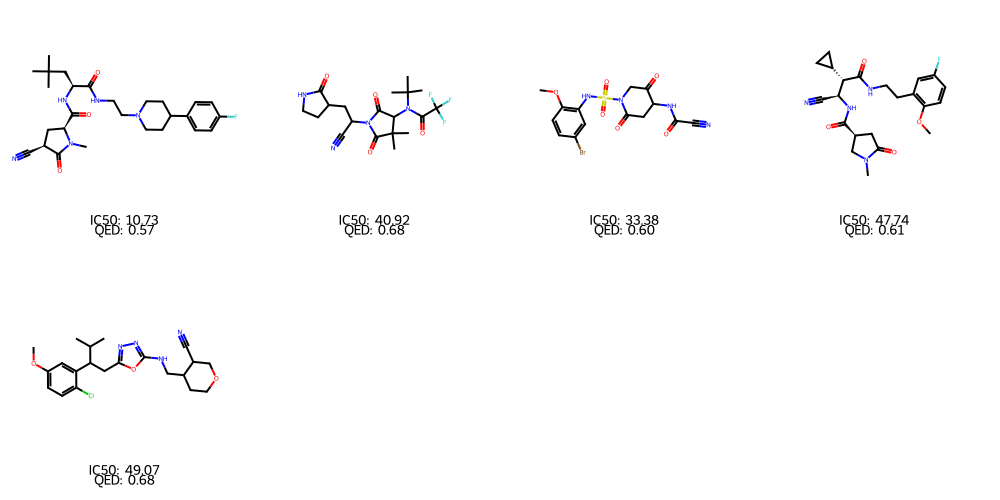

In [35]:
ic50_qed_success = find_success_molecules_ic50_qed(
    ic50_qed_trace,
    target_ic50=50.0,
    min_qed=0.5
)

print("=== IC50 Mpro + QED: Successful Molecules ===")
display_success_grid(ic50_qed_success, "IC50 Mpro + QED", score_keys=["IC50", "QED"])